In [ ]:
from pathlib import Path
import re
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

### This class provides functionality to parse training logs and plot accuracy and loss metrics over epochs.
class AccuracyPlotter:
    def __init__(self, training_path):
        self.training_path = Path(training_path)
        self.metrics = {}
        self.initial_epochs = None
        self._load_metrics()

    def _load_metrics(self):
        training_re = re.compile(
            r"\[Training\]\s+EPOCH:\s*(\d+)\s+EpochTime\s*=\s*([0-9]*\.?[0-9]+)\s*\(s\)\s+Losses\s*=\s*\['([^']+)'\]"
        )
        validation_re = re.compile(
            r"\[Validation\]\s+EPOCH:\s*(\d+)\s+acc\s*=\s*([0-9]*\.?[0-9]+)"
        )
        validation_rot_re = re.compile(
            r"\[Validation_ROT\]\s+EPOCH:\s*(\d+)\s+acc\s*=\s*([0-9]*\.?[0-9]+)"
        )
        lr_re = re.compile(
            r"\[Epoch\s*(\d+)/(\d+)\]\[Batch\s*(\d+)/(\d+)\].*lr\s*=\s*([0-9]*\.?[0-9]+(?:[eE][-+]?\d+)?)"
        )
        warmup_re = re.compile(
            r"config\.scheduler\.kwargs\.initial_epochs\s*[:=]\s*(\d+)"
        )

        for log_file in sorted(self.training_path.glob("*.log")):
            with log_file.open("r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    wm = warmup_re.search(line)
                    if wm and self.initial_epochs is None:
                        self.initial_epochs = int(wm.group(1))

                    m = training_re.search(line)
                    if m:
                        epoch = int(m.group(1))
                        self.metrics.setdefault(epoch, {})
                        self.metrics[epoch]["epochtime"] = float(m.group(2))
                        self.metrics[epoch]["Loss"] = float(m.group(3))
                        continue

                    m = validation_re.search(line)
                    if m:
                        epoch = int(m.group(1))
                        self.metrics.setdefault(epoch, {})
                        self.metrics[epoch]["Validation"] = float(m.group(2))
                        continue

                    m = validation_rot_re.search(line)
                    if m:
                        epoch = int(m.group(1))
                        self.metrics.setdefault(epoch, {})
                        self.metrics[epoch]["Validation_Rot"] = float(m.group(2))
                        continue

                    m = lr_re.search(line)
                    if m:
                        epoch = int(m.group(1))
                        self.metrics.setdefault(epoch, {})
                        self.metrics[epoch]["lr"] = float(m.group(5))

    def print(self):
        for epoch in sorted(self.metrics.keys()):
            print(f"Epoch {epoch}: {self.metrics[epoch]}")

    def plot(self, rotation=False):
        from matplotlib.patches import Patch

        loss_points = []
        val_points = []
        val_rot_points = []
        lr_points = []

        for epoch in sorted(self.metrics.keys()):
            m = self.metrics[epoch]
            if "Loss" in m:
                loss_points.append((epoch, m["Loss"]))
            if "Validation" in m:
                val_points.append((epoch, m["Validation"]))
            if "Validation_Rot" in m and rotation:
                val_rot_points.append((epoch, m["Validation_Rot"]))
            if "lr" in m:
                lr_points.append((epoch, m["lr"]))

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

        if loss_points:
            epochs, losses = zip(*sorted(loss_points))
            ax1.plot(epochs, losses, color="tab:blue", label="Loss")

        if val_points:
            epochs, vals = zip(*sorted(val_points))
            ax2.plot(epochs, vals, color="tab:orange", label="Validation")

        if val_rot_points:
            epochs, vals = zip(*sorted(val_rot_points))
            ax2.plot(epochs, vals, color="tab:red", label="Validation_Rot")

        if lr_points:
            epochs, lrs = zip(*sorted(lr_points))
            ax3.plot(epochs, lrs, color="tab:green", label="Learning rate")

        warmup_patch = None
        if self.initial_epochs and self.metrics:
            first_epoch = min(self.metrics.keys())
            warmup_start = first_epoch - 0.5
            warmup_end = first_epoch + self.initial_epochs - 0.5
            warmup_color = "lightcoral"

            for ax in (ax1, ax2, ax3):
                ax.axvspan(
                    warmup_start,
                    warmup_end,
                    color=warmup_color,
                    alpha=0.25,
                    zorder=0,
                )

            warmup_patch = Patch(
                facecolor=warmup_color,
                alpha=0.25,
                label="Warmup epochs",
            )

        if val_points:
            best_epoch, best_val = max(val_points, key=lambda x: x[1])
            ax2.scatter(best_epoch, best_val, color="tab:orange", zorder=5)
            ax2.annotate(
                f"{best_val:.4f}",
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 2.5, best_val - 0.1),
                color="tab:orange",
                arrowprops=dict(
                    arrowstyle="-",
                    color="tab:orange",
                    connectionstyle="angle,angleA=0,angleB=90",
                ),
            )

        if val_rot_points:
            best_rot_epoch, best_rot_val = max(val_rot_points, key=lambda x: x[1])
            ax2.scatter(best_rot_epoch, best_rot_val, color="tab:red", zorder=5)
            ax2.annotate(
                f"{best_rot_val:.4f}",
                xy=(best_rot_epoch, best_rot_val),
                xytext=(best_rot_epoch + 2.5, best_rot_val - 0.1),
                color="tab:red",
                arrowprops=dict(
                    arrowstyle="-",
                    color="tab:red",
                    connectionstyle="angle,angleA=0,angleB=90",
                ),
            )

        ax1.set_ylabel("MSE")
        ax1.set_title("Loss")
        ax2.set_ylabel("Accuracy")
        ax2.set_title("Accuracy")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel("Learning rate")
        ax3.set_title("Learning Rate")

        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        h3, l3 = ax3.get_legend_handles_labels()

        if warmup_patch is not None:
            for h, l in ((h1, l1), (h2, l2), (h3, l3)):
                h.append(warmup_patch)
                l.append(warmup_patch.get_label())

        if h1:
            ax1.legend(h1, l1, loc="best")
        if h2:
            ax2.legend(h2, l2, loc="best")
        if h3:
            ax3.legend(h3, l3, loc="best")

        plt.tight_layout()
        plt.show()



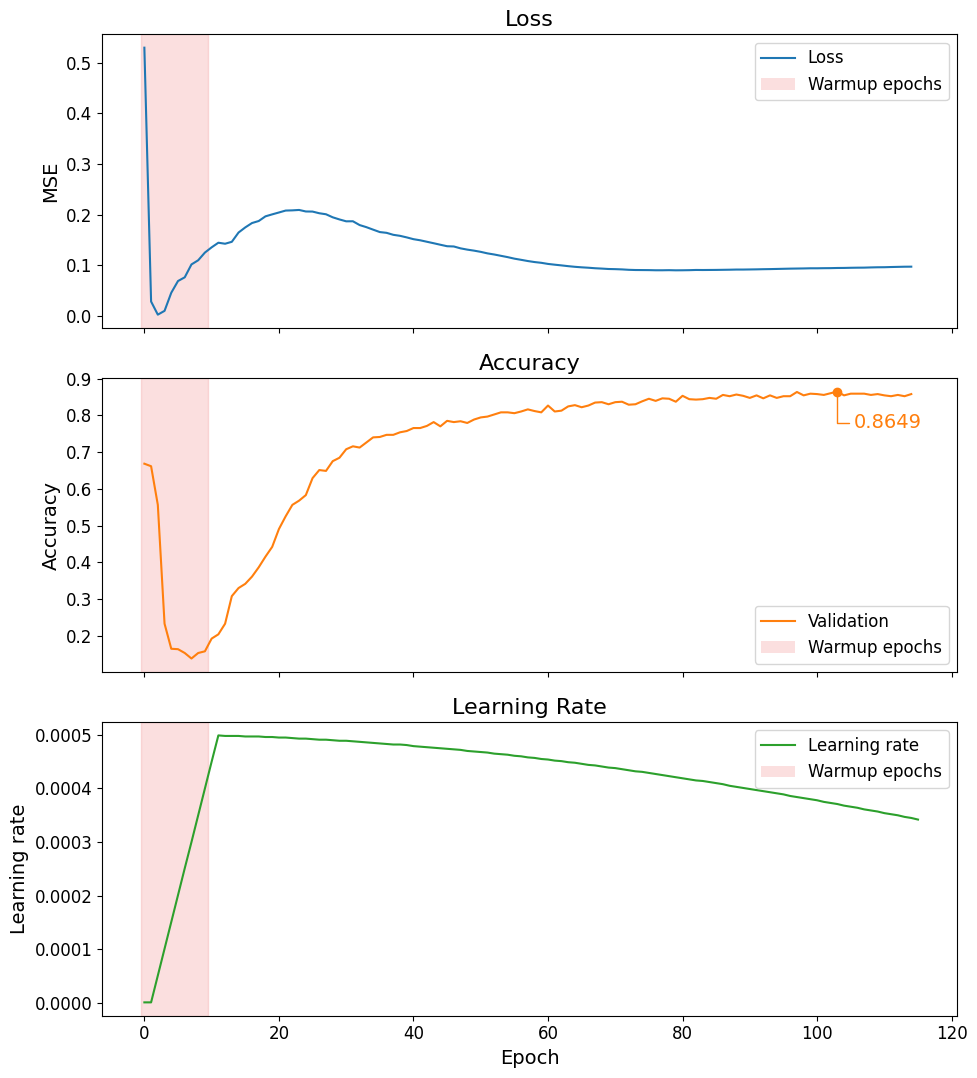

In [ ]:
# Replace with the path to your training logs
TRAINING_PATH = "experiments/RI_MAE/SSL_models/pretrain_abc"
plotter = AccuracyPlotter(TRAINING_PATH)
plotter.plot()